In [14]:
!pip install torch torchvision torchaudio gymnasium gymnasium[classic-control]

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

import numpy as np
import random
import gymnasium as gym
from collections import deque

In [16]:
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cpu
False


In [17]:
# Configuration

HIDDEN_LAYERS     = [256, 256]
LOG_STD_CLAMP     = (-20, 2)

LEARNING_RATE     = 3e-4
OPTIM_EPS         = 1e-5

ROLLOUT_STEPS     = 2048
TOTAL_TIMESTEPS   = 200_000

GAMMA             = 0.99
LAMBDA            = 0.95
PPO_EPOCH         = 10
MINI_BATCH        = 64
CLIP_EPS          = 0.2
VALUE_COEF        = 0.5
ENTROPY_COEF      = 0.01
MAX_GRAD_NORM     = 0.5

DEVICE            = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED              = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
class Actor(nn.Module):
  def __init__(
      self,
      state_dim: int,
      action_dim: int,
      hidden_dim: list[int],
      mean_scale: float,
      clamp: tuple[float, float]
  ):
    super(Actor, self).__init__()
    self.mean_scale = mean_scale
    self.clamp = clamp

    dim = state_dim
    self.backbone = nn.Sequential()
    for i in range(len(hidden_dim)):
      self.backbone.append(nn.Linear(dim, hidden_dim[i]))
      self.backbone.append(nn.Tanh())
      dim = hidden_dim[i]

    # actor head
    self.actor_net = nn.Linear(dim, action_dim)
    self.log_std = nn.Parameter(torch.full((action_dim,), -0.5))

    self._init_weights()

  def _init_weights(self):
    for m in self.backbone:
      if isinstance(m, nn.Linear):
        nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
        nn.init.zeros_(m.bias)

    for m in self.actor_net:
      if isinstance(m, nn.Linear):
        nn.init.orthogonal_(m.weight, gain=0.01)
        nn.init.zeros_(m.bias)

  def forward(self, x: torch.Tensor):
    x = self.backbone(x)
    actor_mean = self.actor_net(x)
    log_std = self.log_std.clamp(*self.clamp)
    std = log_std.exp().expand_as(actor_mean)
    dist = Normal(actor_mean, std)

    return dist

In [19]:
class Critic(nn.Module):
  def __init__(self, state_dim: int, hidden_dim: list[int]):
    super(Critic, self).__init__()

    dim = state_dim
    self.backbone = nn.Sequential()
    for i in range(len(hidden_dim)):
      self.backbone.append(nn.Linear(dim, hidden_dim[i]))
      self.backbone.append(nn.Tanh())
      dim = hidden_dim[i]

    self.critic_net = nn.Linear(dim, 1)
    self._init_weights()

  def _init_weights(self):
    for m in self.backbone:
      if isinstance(m, nn.Linear):
        nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
        nn.init.zeros_(m.bias)

    nn.init.orthogonal_(self.critic_net.weight, gain=1)
    nn.init.zeros_(self.critic_net.bias)

  def forward(self, x: torch.Tensor):
    x = self.backbone(x)
    value = self.critic_net(x).squeeze(-1)
    return value

  @torch.no_grad()
  def get_value(self, x: torch.Tensor):
    return self.critic_net(self.backbone(x)).squeeze(-1)

In [20]:
class RolloutBuffer:
  def __init__(self, rollout_steps: int, state_dim: int, action_dim: int):
    # allocate buffer
    self.states         = np.zeros((rollout_steps, state_dim),   dtype=np.float32)
    self.actions        = np.zeros((rollout_steps, action_dim),  dtype=np.float32)
    self.rewards        = np.zeros(rollout_steps,                dtype=np.float32)
    self.dones          = np.zeros(rollout_steps,                dtype=np.float32)
    self.values         = np.zeros(rollout_steps,                dtype=np.float32)
    self.log_probs      = np.zeros(rollout_steps,                dtype=np.float32)
    self.pointer        = 0

  def store(self, state, action, reward, done, value, log_prob):
    self.states[self.pointer]         = state
    self.actions[self.pointer]        = action
    self.rewards[self.pointer]        = reward
    self.dones[self.pointer]          = done
    self.values[self.pointer]         = value
    self.log_probs[self.pointer]      = log_prob
    self.pointer                      += 1

  def compute_gae(self, last_value, gamma: float, lam: float):
    T = self.pointer
    advantages = np.zeros(T, dtype=np.float32)
    gae = 0.0

    for i in reversed(range(T)):
      next_value      = last_value if i == T - 1 else self.values[i + 1]
      mask            = 1.0 - self.dones[i]

      delta = self.rewards[i] + (gamma * next_value * mask) - self.values[i]
      gae = delta + (gamma * lam * mask * gae)
      advantages[i] = gae

    returns = advantages + self.values[:T]
    return advantages, returns

  def get_tensor(self):
    T = self.pointer
    return (
        torch.FloatTensor(self.states[:T]).to(DEVICE),
        torch.FloatTensor(self.actions[:T]).to(DEVICE),
        torch.FloatTensor(self.log_probs[:T]).to(DEVICE),
    )

  def reset(self):
    self.pointer = 0


In [ ]:
class PPOAgent:
  def __init__(self, state_dim: int, action_dim: int, total_timesteps: int, rollout_steps: int, action_scale: float):
    self.actor_net = Actor(state_dim, action_dim, HIDDEN_LAYERS, action_scale, LOG_STD_CLAMP).to(DEVICE)
    self.critic_net = Critic(state_dim, HIDDEN_LAYERS).to(DEVICE)

    self.actor_optim    = optim.Adam(self.actor_net.parameters(), lr=LEARNING_RATE, eps=OPTIM_EPS)
    self.critic_optim   = optim.Adam(self.critic_net.parameters(), lr=LEARNING_RATE, eps=OPTIM_EPS)
    self.buffer = RolloutBuffer(rollout_steps, state_dim, action_dim)

    self.total_timesteps  = total_timesteps
    self.rollout_steps    = rollout_steps
    self.update_count     = 0
    self.total_updates    = total_timesteps // rollout_steps
    self.action_scale      = action_scale

  @torch.no_grad()
  def select_action(self, state: np.ndarray):
    state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
    dist = self.actor_net(state_t)
    raw_action = dist.rsample()

    action = torch.tanh(raw_action)
    log_prob = (dist.log_prob(raw_action) - torch.log(1 - action.pow(2) + 1e-6)).sum(-1)
    action = action * self.action_scale

    value = self.critic_net(state_t)
    action_np = action.squeeze(0).cpu().numpy()
    return action_np, raw_action.squeeze(0).cpu().numpy(), log_prob.item(), value.item()

  def _anneal_lr(self):
    frac = 1.0 - (self.update_count / self.total_updates)
    lr = LEARNING_RATE * frac
    for param_group in self.actor_optim.param_groups:
      param_group['lr'] = lr

    for param_group in self.critic_optim.param_groups:
      param_group['lr'] = lr

  def learn(self, last_value):
    self._anneal_lr()
    self.update_count += 1

    advantage, returns = self.buffer.compute_gae(last_value, GAMMA, LAMBDA)

    adv_t = torch.FloatTensor(advantage).to(DEVICE)
    ret_t = torch.FloatTensor(returns).to(DEVICE)

    # advantage normalization with z-score normalization
    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8) # 1e-8 prevent for division by zero of std()

    states_t, actions_t, log_probs_t = self.buffer.get_tensor()
    total_size = len(states_t)
    indicies = np.arange(total_size)

    for _ in range(PPO_EPOCH):
      np.random.shuffle(indicies)

      for start in range(0, total_size, MINI_BATCH):
        end = start + MINI_BATCH
        mb_idx = indicies[start:end]

        mb_states         = states_t[mb_idx]
        mb_actions        = actions_t[mb_idx]
        mb_log_probs      = log_probs_t[mb_idx]
        mb_adv            = adv_t[mb_idx]
        mb_ret            = ret_t[mb_idx]

        new_dist              = self.actor_net(mb_states)
        tanh_mb_raw_actions   = torch.tanh(mb_actions)
        new_log_probs         = (new_dist.log_prob(mb_actions) - torch.log(1 - tanh_mb_raw_actions.pow(2) + 1e-6)).sum(-1)
        entropy               = new_dist.entropy().sum(-1).mean()

        # Clipped policy loss
        ratio = (new_log_probs - mb_log_probs).exp()
        surr1 = ratio * mb_adv
        surr2 = torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * mb_adv
        pg_loss = -torch.min(surr1, surr2).mean()
        actor_loss = pg_loss - ENTROPY_COEF * entropy

        # value loss
        new_values  = self.critic_net(mb_states)
        vf_loss     = 0.5 * (new_values - mb_ret).pow(2).mean()


        self.actor_optim.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor_net.parameters(), MAX_GRAD_NORM)
        self.actor_optim.step()

        self.critic_optim.zero_grad()
        vf_loss.backward()
        nn.utils.clip_grad_norm_(self.critic_net.parameters(), MAX_GRAD_NORM)
        self.critic_optim.step()

    self.buffer.reset()

In [22]:
# Pendulum Env

def train():
  env = gym.make('Pendulum-v1')

  state_dim = env.observation_space.shape[0]
  action_dim = env.action_space.shape[0]
  action_scale = env.action_space.high[0]
  agent = PPOAgent(state_dim, action_dim, TOTAL_TIMESTEPS, ROLLOUT_STEPS, action_scale)

  total_steps = 0
  episode_count = 0
  history = []

  state, _ = env.reset()
  ep_reward = 0.0
  ep_steps = 0

  while total_steps < TOTAL_TIMESTEPS:
    for step in range(ROLLOUT_STEPS):
      action, raw_action, log_prob, value = agent.select_action(state)
      next_state, reward, terminated, truncated, _ = env.step(action)
      done = terminated or truncated

      agent.buffer.store(state, raw_action, reward, float(terminated), value, log_prob)
      state = next_state
      ep_reward += reward
      ep_steps += 1
      total_steps += 1

      if done:
        history.append(ep_reward)
        episode_count += 1

        # LOGGING
        if episode_count % 10 == 0:
          avg    = np.mean(history[-10:])
          lr_now = agent.actor_optim.param_groups[0]["lr"]
          print(
              f"Ep {episode_count:5d} | "
              f"Steps {total_steps:8,d} | "
              f"Avg-{10}: {avg:8.1f} | "
              f"Best-last-10: {np.max(history[-10:]):7.1f} | "
              f"LR: {lr_now:.2e}"
          )

        ep_reward = 0.0
        ep_steps = 0
        state, _ = env.reset()

    with torch.no_grad():
      state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
      last_value = agent.critic_net.get_value(state_t).item()

    agent.learn(last_value)

  env.close()
  return agent, history


In [23]:
agent, history = train()

print("\nTraining selesai!")
print(f"Total episode: {len(history)}")
print(f"Reward akhir (rata-rata semua episode): {np.mean(history):.1f}")

Ep    10 | Steps    2,000 | Avg-10:  -1202.2 | Best-last-10:  -920.9 | LR: 3.00e-04
Ep    20 | Steps    4,000 | Avg-10:  -1178.6 | Best-last-10:  -671.9 | LR: 3.00e-04
Ep    30 | Steps    6,000 | Avg-10:  -1186.9 | Best-last-10:  -873.9 | LR: 2.97e-04
Ep    40 | Steps    8,000 | Avg-10:  -1092.0 | Best-last-10:  -752.1 | LR: 2.94e-04
Ep    50 | Steps   10,000 | Avg-10:  -1130.5 | Best-last-10:  -798.3 | LR: 2.91e-04
Ep    60 | Steps   12,000 | Avg-10:  -1142.8 | Best-last-10:  -874.9 | LR: 2.88e-04
Ep    70 | Steps   14,000 | Avg-10:  -1078.3 | Best-last-10:  -871.1 | LR: 2.85e-04
Ep    80 | Steps   16,000 | Avg-10:  -1120.7 | Best-last-10:  -878.3 | LR: 2.81e-04
Ep    90 | Steps   18,000 | Avg-10:  -1008.8 | Best-last-10:  -763.1 | LR: 2.78e-04
Ep   100 | Steps   20,000 | Avg-10:  -1186.8 | Best-last-10:  -770.8 | LR: 2.75e-04
Ep   110 | Steps   22,000 | Avg-10:   -974.5 | Best-last-10:  -757.2 | LR: 2.72e-04
Ep   120 | Steps   24,000 | Avg-10:  -1097.5 | Best-last-10:  -850.0 | LR: 2

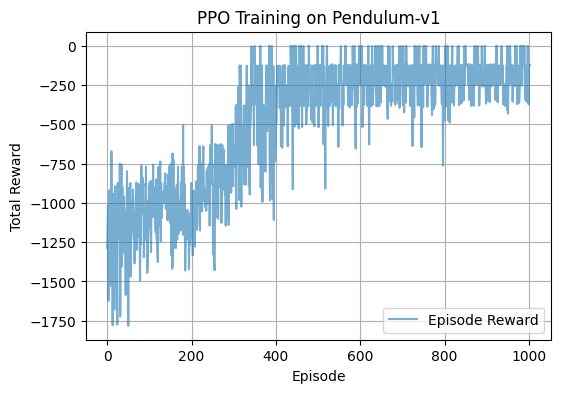

In [27]:
import matplotlib.pyplot as plt

import numpy as np

plt.figure(figsize=(6, 4))
plt.plot(history, alpha=0.6, label="Episode Reward")
plt.title("PPO Training on Pendulum-v1")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()
plt.show()